## Inventory & Stock Analysis 
Retail Inventory Optimization & Stock Movement Analysis


## Load Data 

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv
/kaggle/input/datasets/mamtapathak/superstore-datasets/sample superstore.xls


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv',encoding='latin1')

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Select Columns

In [5]:
df = df[[ 'Product Name', 'Category', 'Sales', 'Quantity', 'Profit', 'Discount']]

df.head()

,Product Name,Category,Sales,Quantity,Profit,Discount
0,Bush Somerset Collection Bookcase,Furniture,261.9600,2,41.9136,0.00
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,731.9400,3,219.5820,0.00
2,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,14.6200,2,6.8714,0.00
3,Bretford CR4500 Series Slim Rectangular Table,Furniture,957.5775,5,-383.0310,0.45
4,Eldon Fold 'N Roll Cart System,Office Supplies,22.3680,2,2.5164,0.20


## Product level Aggregation

In [6]:
# How much product re sold ,How many are sold ,How profitable they are 


product_df = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Quantity': 'sum',
    'Profit': 'sum'
}).reset_index()

In [7]:
df.shape

product_df.head()

,Product Name,Sales,Quantity,Profit
0,"""While you Were Out"" Message Book, One Form pe...",25.228,8,10.3880
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,11,16.7678
2,#10 Self-Seal White Envelopes,108.682,10,52.1230
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904,32,223.1408
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,37,115.2806


## Visualization 
Sales vs Profit  plot

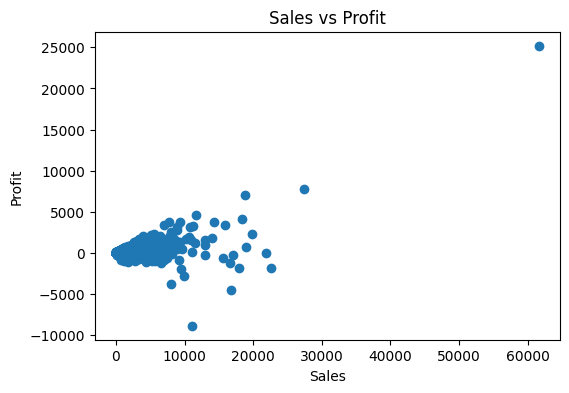

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(product_df['Sales'], product_df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

<Axes: >

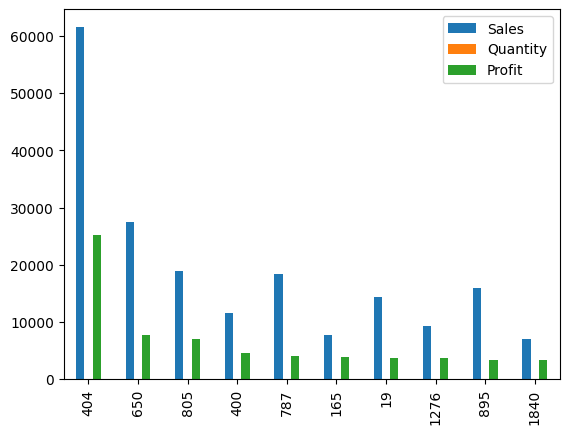

In [9]:
# 10 best products

product_df.sort_values('Profit', ascending=False).head(10).plot(kind = 'bar')

<Axes: >

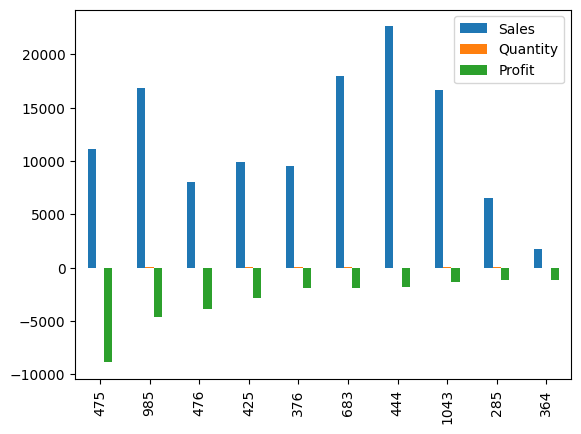

In [10]:
# 10 worst products 

product_df.sort_values('Profit').head(10).plot(kind = 'bar')

## Key Insights
* Profit is driven by a small group of products (mainly copiers/printers).
*  High sales does not always mean high profit.
* Furniture and some large equipment cause most losses.
* Loss-making items are specific products, not whole categories.
* Quantity sold is not a strong indicator of profitability.


## Final Conclusion

The business is structurally dependent on a small set of high-performing products to remain profitable. While overall sales volume appears strong, profitability is uneven and vulnerable due to losses concentrated in specific items.

This indicates a need for:
* better product pricing strategy
* review of underperforming SKUs
* tighter control on cost-heavy products
* stronger focus on high-margin product lines